## ECG ink removal - Laplacian pyramid experiment

This notebook studies **ink removal**, not alignment.
We use the same synthetic setup as the other notebooks.

### Idea
A Laplacian pyramid separates the image into scales.

- broad stains and smudges live more in the **coarse** levels
- thin ECG lines live more in the **fine** levels

So we will:
1. load one clean ECG image,
2. add synthetic ink,
3. build Gaussian and Laplacian pyramids,
4. correct only the **coarsest Gaussian level** with morphology,
5. reconstruct the image with the original Laplacian details.

### Goal
The goal is simple:
- remove broad dark ink at coarse scale,
- keep ECG details from the fine scales.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------
# Configuration
# ---------------------------------
base_path = Path("../../data/sample")
selected_ecg_id = "11842146"
clean_scan = "0001"

# Synthetic ink
RANDOM_SEED = 19
N_STROKES = 15
N_BLOBS = 8
N_SMUDGES = 5

# Pyramid
PYRAMID_LEVELS = 6
COARSE_CLOSING_KERNEL = 11


## Helper functions

These functions keep the workflow short.
The main experiment stays step by step.


In [2]:
def load_gray_image(ecg_id, scan_type):
    path = base_path / ecg_id / f"{ecg_id}-{scan_type}.png"
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {path}")
    return img.astype(np.float32) / 255.0, path


def to_u8(img):
    return np.clip(np.round(img * 255.0), 0, 255).astype(np.uint8)


def masked_mae(a, b, mask):
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(a[mask] - b[mask])))


def normalize_for_display(img):
    img = img.astype(np.float32)
    lo = float(img.min())
    hi = float(img.max())
    if hi - lo < 1e-8:
        return np.zeros_like(img)
    return (img - lo) / (hi - lo)


def odd_kernel_size(k):
    k = int(k)
    if k < 3:
        k = 3
    if k % 2 == 0:
        k += 1
    return k


def generate_random_ink_from_clean(clean_img, seed=7, n_strokes=14, n_blobs=10, n_smudges=4):
    rng = np.random.default_rng(seed)
    h, w = clean_img.shape

    stroke_layer = np.zeros((h, w), dtype=np.float32)
    blob_layer = np.zeros((h, w), dtype=np.float32)
    smudge_layer = np.zeros((h, w), dtype=np.float32)

    # Dark thin strokes.
    for _ in range(n_strokes):
        x1 = int(rng.integers(0, w))
        y1 = int(rng.integers(0, h))
        length = int(rng.integers(min(h, w) // 30, min(h, w) // 8))
        angle = float(rng.uniform(0, 2 * np.pi))
        x2 = int(np.clip(x1 + length * np.cos(angle), 0, w - 1))
        y2 = int(np.clip(y1 + length * np.sin(angle), 0, h - 1))
        thickness = int(rng.integers(2, 8))
        value = float(rng.uniform(0.18, 0.45))
        cv2.line(stroke_layer, (x1, y1), (x2, y2), value, thickness, lineType=cv2.LINE_AA)

    # Compact blobs.
    for _ in range(n_blobs):
        center = (int(rng.integers(0, w)), int(rng.integers(0, h)))
        axes = (
            int(rng.integers(max(4, w // 80), max(8, w // 25))),
            int(rng.integers(max(4, h // 80), max(8, h // 25))),
        )
        angle = float(rng.uniform(0, 180))
        value = float(rng.uniform(0.10, 0.60))
        cv2.ellipse(blob_layer, center, axes, angle, 0, 360, value, -1, lineType=cv2.LINE_AA)

    # Broad faint smudges.
    for _ in range(n_smudges):
        center = (int(rng.integers(0, w)), int(rng.integers(0, h)))
        axes = (
            int(rng.integers(max(20, w // 25), max(40, w // 10))),
            int(rng.integers(max(20, h // 25), max(40, h // 10))),
        )
        angle = float(rng.uniform(0, 180))
        value = float(rng.uniform(0.03, 0.50))
        cv2.ellipse(smudge_layer, center, axes, angle, 0, 360, value, -1, lineType=cv2.LINE_AA)

    blob_layer = cv2.GaussianBlur(blob_layer, (0, 0), sigmaX=3, sigmaY=3)
    smudge_layer = cv2.GaussianBlur(smudge_layer, (0, 0), sigmaX=11, sigmaY=11)

    darkening = np.clip(stroke_layer + blob_layer + smudge_layer, 0.0, 0.99)
    synthetic_ink = np.clip(clean_img - darkening, 0.0, 1.0)
    true_ink_mask = darkening > 0.03
    return synthetic_ink, darkening, true_ink_mask


def build_gaussian_pyramid(img, levels):
    pyramid = [img.astype(np.float32)]
    for _ in range(levels - 1):
        pyramid.append(cv2.pyrDown(pyramid[-1]))
    return pyramid


def build_laplacian_pyramid(gaussian_pyramid):
    pyramid = []
    for level in range(len(gaussian_pyramid) - 1):
        current = gaussian_pyramid[level]
        next_level = gaussian_pyramid[level + 1]
        up = cv2.pyrUp(next_level, dstsize=(current.shape[1], current.shape[0]))
        pyramid.append(current - up)
    pyramid.append(gaussian_pyramid[-1])
    return pyramid


def reconstruct_from_laplacian_pyramid(laplacian_pyramid):
    current = laplacian_pyramid[-1].astype(np.float32)
    for level in range(len(laplacian_pyramid) - 2, -1, -1):
        target_h, target_w = laplacian_pyramid[level].shape
        current = cv2.pyrUp(current, dstsize=(target_w, target_h))
        current = np.clip(current + laplacian_pyramid[level], 0.0, 1.0)
    return current


def expand_pyramid_base_to_full(base_level, gaussian_pyramid):
    current = base_level.astype(np.float32)
    for level in range(len(gaussian_pyramid) - 2, -1, -1):
        target_h, target_w = gaussian_pyramid[level].shape
        current = cv2.pyrUp(current, dstsize=(target_w, target_h))
    return np.clip(current, 0.0, 1.0)


def close_grayscale_image(img, kernel_size):
    kernel_size = odd_kernel_size(kernel_size)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    img_u8 = to_u8(img)
    closed_u8 = cv2.morphologyEx(img_u8, cv2.MORPH_CLOSE, kernel)
    return closed_u8.astype(np.float32) / 255.0


## Step 1 - Load the clean image

We start from one clean ECG image.
This is the reference target.


ECG ID: 11842146
Clean path: ..\..\data\sample\11842146\11842146-0001.png
Shape: (1700, 2200)


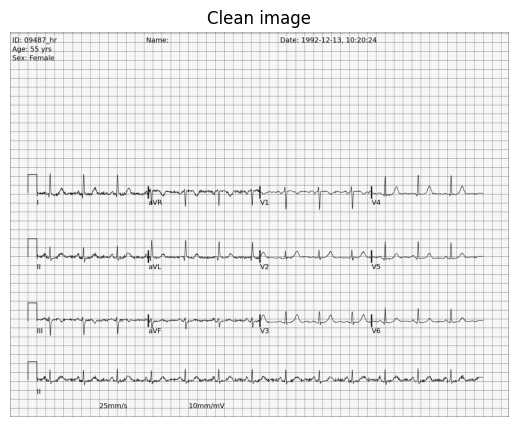

In [3]:
clean_img, clean_path = load_gray_image(selected_ecg_id, clean_scan)
full_mask = np.ones_like(clean_img, dtype=bool)

print("ECG ID:", selected_ecg_id)
print("Clean path:", clean_path)
print("Shape:", clean_img.shape)

plt.figure(figsize=(12, 5))
plt.imshow(clean_img, cmap="gray")
plt.title("Clean image")
plt.axis("off")
plt.show()


## Step 2 - Add synthetic ink

We create one synthetic ink image from the clean ECG.
The true synthetic ink mask is known.


Random seed: 19
MAE before processing on all pixels : 0.015498
MAE before processing on ink mask   : 0.169262
True synthetic mask pixels: 336648


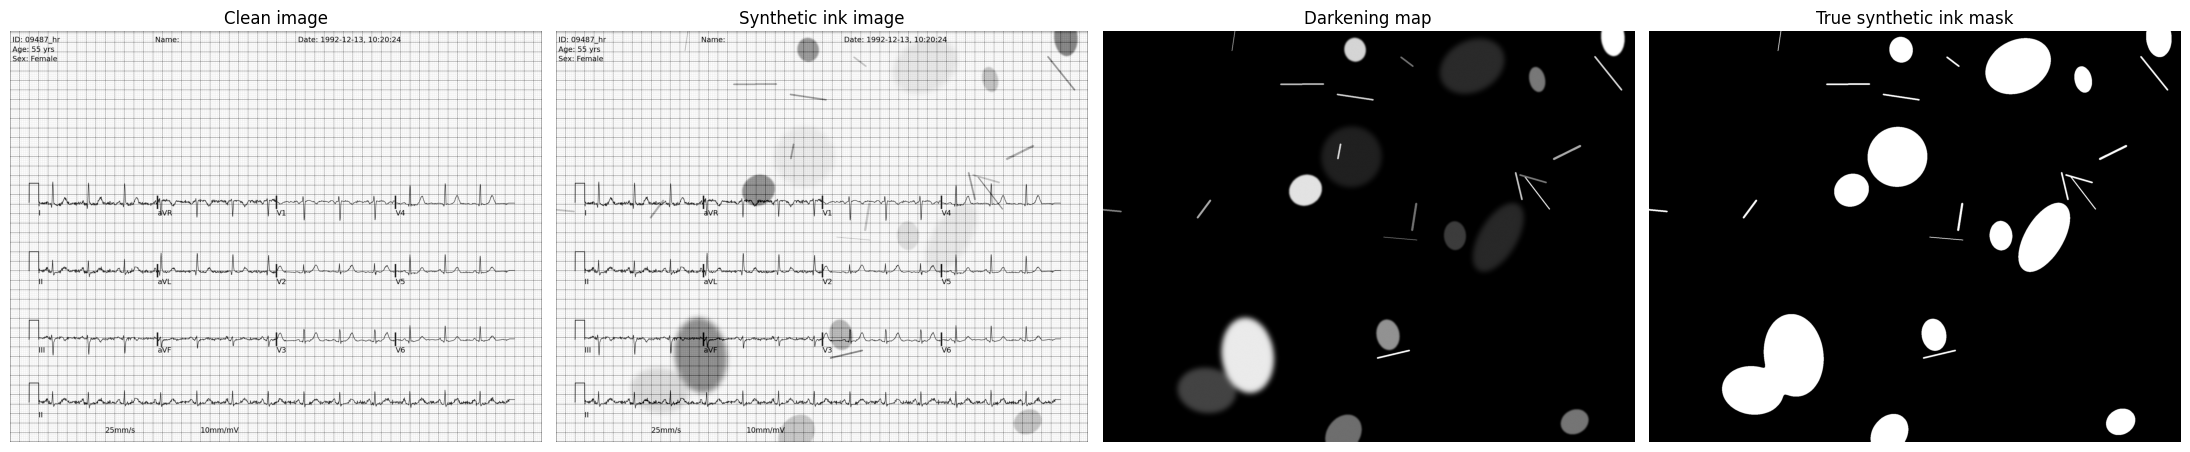

In [4]:
synthetic_ink, darkening_map, true_ink_mask = generate_random_ink_from_clean(
    clean_img,
    seed=RANDOM_SEED,
    n_strokes=N_STROKES,
    n_blobs=N_BLOBS,
    n_smudges=N_SMUDGES,
)

mae_before_all = masked_mae(synthetic_ink, clean_img, full_mask)
mae_before_ink = masked_mae(synthetic_ink, clean_img, true_ink_mask)

print("Random seed:", RANDOM_SEED)
print(f"MAE before processing on all pixels : {mae_before_all:.6f}")
print(f"MAE before processing on ink mask   : {mae_before_ink:.6f}")
print("True synthetic mask pixels:", int(true_ink_mask.sum()))

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
axes[0].imshow(clean_img, cmap="gray")
axes[0].set_title("Clean image")
axes[0].axis("off")
axes[1].imshow(synthetic_ink, cmap="gray")
axes[1].set_title("Synthetic ink image")
axes[1].axis("off")
axes[2].imshow(darkening_map, cmap="gray")
axes[2].set_title("Darkening map")
axes[2].axis("off")
axes[3].imshow(true_ink_mask, cmap="gray")
axes[3].set_title("True synthetic ink mask")
axes[3].axis("off")
plt.tight_layout()
plt.show()


## Step 3 - Build the pyramids

The Gaussian pyramid keeps coarser versions of the image.
The Laplacian pyramid keeps the detail lost between scales.


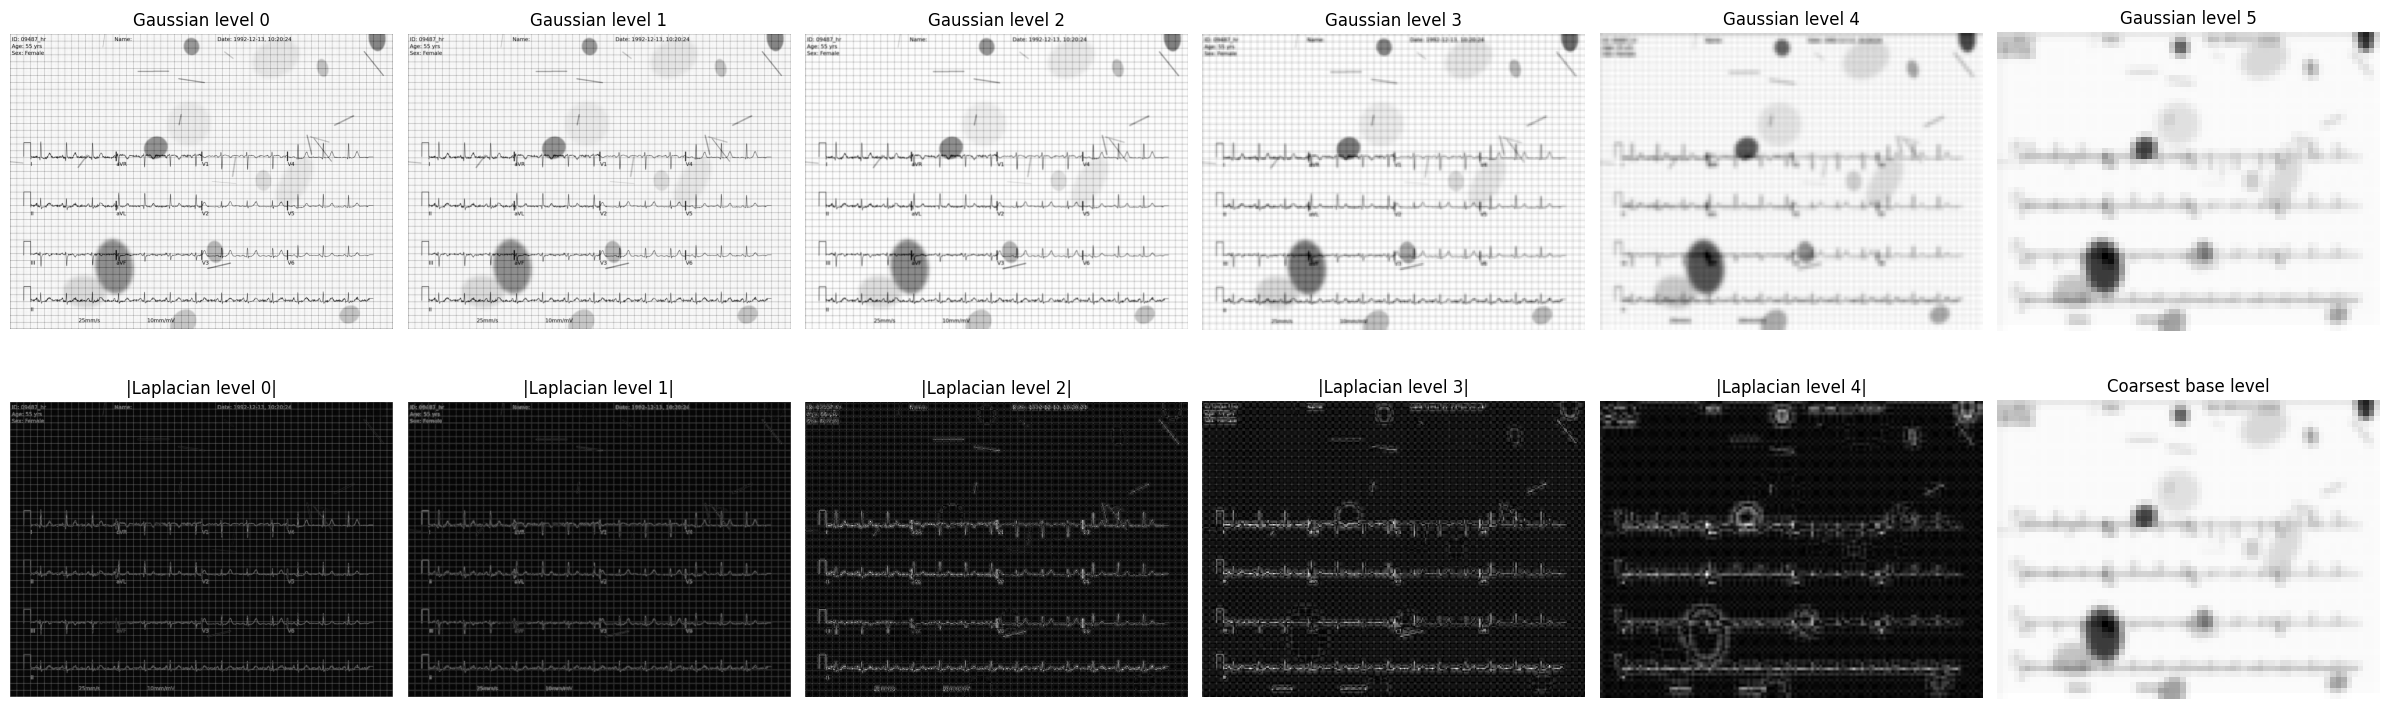

In [5]:
gaussian_pyramid = build_gaussian_pyramid(synthetic_ink, PYRAMID_LEVELS)
laplacian_pyramid = build_laplacian_pyramid(gaussian_pyramid)

fig, axes = plt.subplots(2, PYRAMID_LEVELS, figsize=(4 * PYRAMID_LEVELS, 8))

for level in range(PYRAMID_LEVELS):
    axes[0, level].imshow(gaussian_pyramid[level], cmap="gray")
    axes[0, level].set_title(f"Gaussian level {level}")
    axes[0, level].axis("off")

    if level < PYRAMID_LEVELS - 1:
        lap_display = normalize_for_display(np.abs(laplacian_pyramid[level]))
        axes[1, level].imshow(lap_display, cmap="gray")
        axes[1, level].set_title(f"|Laplacian level {level}|")
    else:
        axes[1, level].imshow(laplacian_pyramid[level], cmap="gray")
        axes[1, level].set_title("Coarsest base level")
    axes[1, level].axis("off")

plt.tight_layout()
plt.show()


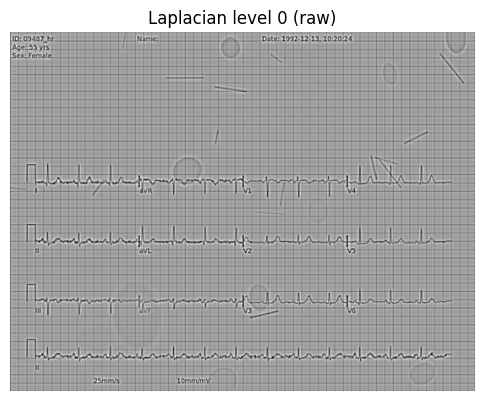

In [23]:
# Show laplacian level 0
# Show laplacian level 0 (raw)
level = 2
img_debug=laplacian_pyramid[4]
plt.figure(figsize=(6, 6))
plt.imshow(laplacian_pyramid[level], cmap="gray")
plt.title("Laplacian level 0 (raw)")
plt.axis("off")
plt.show()


## Step 4 - Correct only the coarse level

We apply closing only to the coarsest Gaussian image.
This is where broad stains should be easier to remove.


Coarsest level shape: (54, 69)
Coarse closing kernel: 11


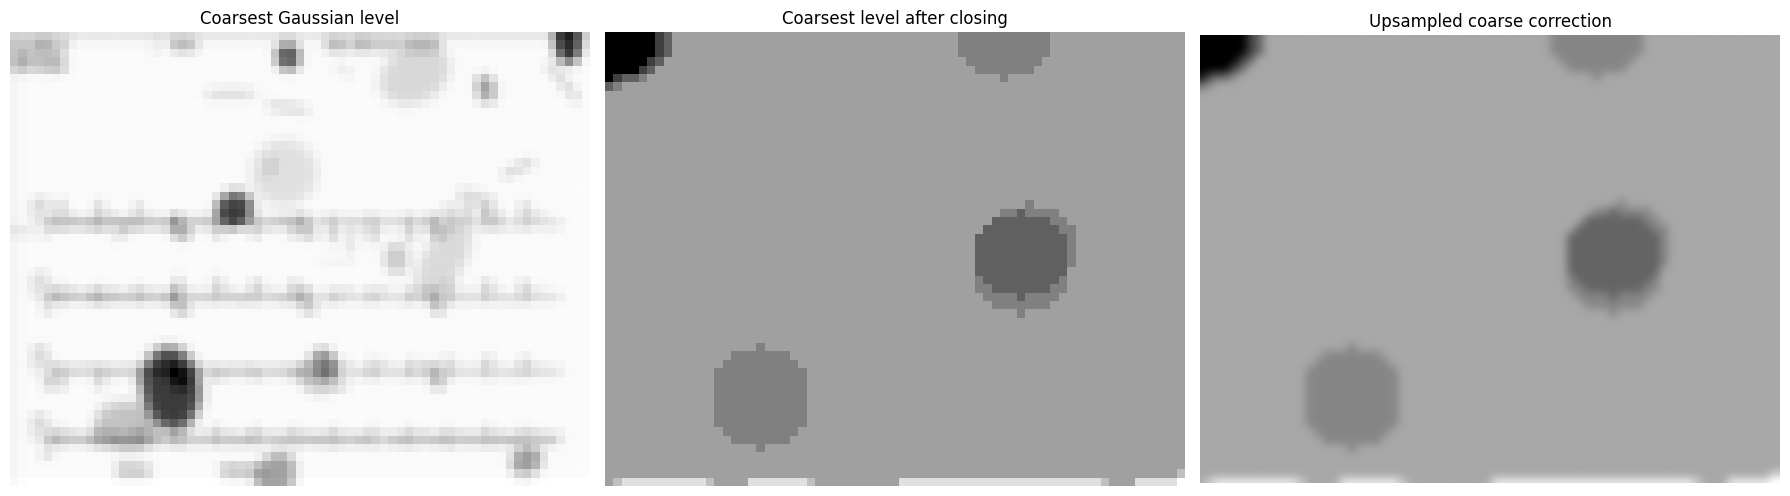

In [6]:
coarse_ink = gaussian_pyramid[-1]
coarse_closed = close_grayscale_image(coarse_ink, COARSE_CLOSING_KERNEL)
coarse_closed_up = expand_pyramid_base_to_full(coarse_closed, gaussian_pyramid)

print("Coarsest level shape:", coarse_ink.shape)
print("Coarse closing kernel:", odd_kernel_size(COARSE_CLOSING_KERNEL))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(coarse_ink, cmap="gray")
axes[0].set_title("Coarsest Gaussian level")
axes[0].axis("off")
axes[1].imshow(coarse_closed, cmap="gray")
axes[1].set_title("Coarsest level after closing")
axes[1].axis("off")
axes[2].imshow(coarse_closed_up, cmap="gray")
axes[2].set_title("Upsampled coarse correction")
axes[2].axis("off")
plt.tight_layout()
plt.show()


## Step 5 - Reconstruct with the Laplacian details

Now we keep the original fine details from the synthetic ink image.
We replace only the coarse base level, then reconstruct.


MAE before processing on all pixels : 0.015498
MAE coarse-up on all pixels         : 0.095457
MAE pyramid restore on all pixels   : 0.011990

MAE before processing on ink mask   : 0.169262
MAE coarse-up on ink mask           : 0.095816
MAE pyramid restore on ink mask     : 0.041601


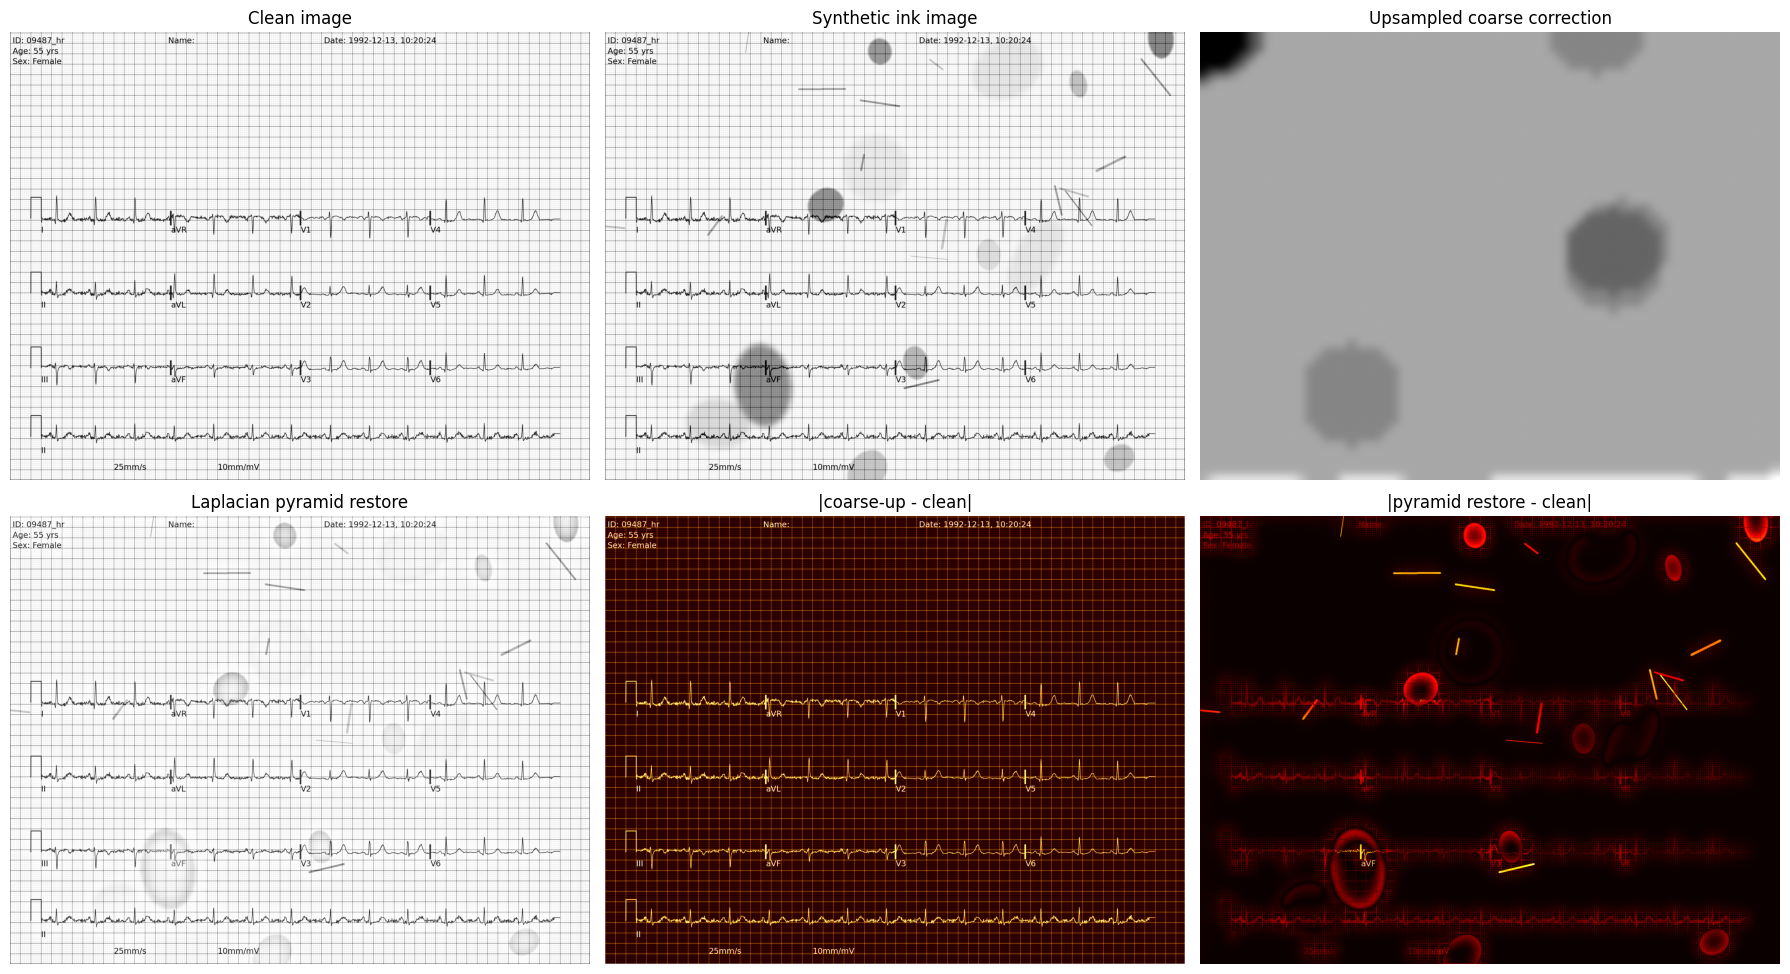

synthetic_ink
  MAE on true ink mask : 0.16926197707653046
  MAE outside ink mask : 0.0002879705571103841
coarse_closed_up
  MAE on true ink mask : 0.09581585973501205
  MAE outside ink mask : 0.09542166441679001
pyramid_restore
  MAE on true ink mask : 0.0416005402803421
  MAE outside ink mask : 0.009060531854629517


In [7]:
restored_laplacian_pyramid = [level.copy() for level in laplacian_pyramid]
restored_laplacian_pyramid[-1] = coarse_closed
pyramid_restore = reconstruct_from_laplacian_pyramid(restored_laplacian_pyramid)

mae_coarse_up_all = masked_mae(coarse_closed_up, clean_img, full_mask)
mae_pyramid_all = masked_mae(pyramid_restore, clean_img, full_mask)
mae_coarse_up_ink = masked_mae(coarse_closed_up, clean_img, true_ink_mask)
mae_pyramid_ink = masked_mae(pyramid_restore, clean_img, true_ink_mask)

print(f"MAE before processing on all pixels : {mae_before_all:.6f}")
print(f"MAE coarse-up on all pixels         : {mae_coarse_up_all:.6f}")
print(f"MAE pyramid restore on all pixels   : {mae_pyramid_all:.6f}")
print()
print(f"MAE before processing on ink mask   : {mae_before_ink:.6f}")
print(f"MAE coarse-up on ink mask           : {mae_coarse_up_ink:.6f}")
print(f"MAE pyramid restore on ink mask     : {mae_pyramid_ink:.6f}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes[0, 0].imshow(clean_img, cmap="gray")
axes[0, 0].set_title("Clean image")
axes[0, 0].axis("off")
axes[0, 1].imshow(synthetic_ink, cmap="gray")
axes[0, 1].set_title("Synthetic ink image")
axes[0, 1].axis("off")
axes[0, 2].imshow(coarse_closed_up, cmap="gray")
axes[0, 2].set_title("Upsampled coarse correction")
axes[0, 2].axis("off")
axes[1, 0].imshow(pyramid_restore, cmap="gray")
axes[1, 0].set_title("Laplacian pyramid restore")
axes[1, 0].axis("off")
axes[1, 1].imshow(np.abs(coarse_closed_up - clean_img), cmap="hot")
axes[1, 1].set_title("|coarse-up - clean|")
axes[1, 1].axis("off")
axes[1, 2].imshow(np.abs(pyramid_restore - clean_img), cmap="hot")
axes[1, 2].set_title("|pyramid restore - clean|")
axes[1, 2].axis("off")
plt.tight_layout()
plt.show()

candidates = {
    "synthetic_ink": synthetic_ink,
    "coarse_closed_up": coarse_closed_up,
    "pyramid_restore": pyramid_restore,
}

for name, img in candidates.items():
    print(name)
    print("  MAE on true ink mask :", masked_mae(img, clean_img, true_ink_mask))
    print("  MAE outside ink mask :", masked_mae(img, clean_img, ~true_ink_mask))


## Conclusion

Saved result on `11842146`:
- before processing: all-pixel MAE `0.015498`, ink-mask MAE `0.169262`
- coarse-up only: all-pixel MAE `0.095457`, ink-mask MAE `0.095816`
- Laplacian pyramid restore: all-pixel MAE `0.011990`, ink-mask MAE `0.041601`

So the coarse correction alone is too blurry and hurts the image badly.
The Laplacian reconstruction brings back useful fine detail and becomes much better than the coarse-up image.
This makes the pyramid idea valid, but it is still weaker than the direct black-hat result.
